# <span style="color: purple;">Lesson 10 - Image Classification</span>

**Developers:** Aditya & Brian | **Reviewers:** Alina

---

## <span style="color: purple;">🎯 Learning Objectives</span>

By the end of this lesson, you will have:

- Loaded and explored a real-world image dataset (CIFAR-10)
- Understood the structure of colour images (**RGB channels**)
- Linked the idea of individual pixel values to "features" (💪 as in previous lessons)
- Trained a simple "flat" model and a **Convolutional Neural Network (CNN)**
- Compared how each architecture performs on identifying complex objects like cars and aeroplanes

<div class="alert alert-info">

**How it works:** Click the ▶ button on the top left of each code cell, top to bottom. Read the explanation after you see the output. That's it!

</div>

In [10]:
# ───────────────────────────────────────────────────────────
# Setup cell — run this first, then you can ignore it
# ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

print("✓ Ready to go!")

✓ Ready to go!


---

## <span style="color: purple;">🎨 The Mathematical Representation of a Colour Image</span>

### From pixels to numbers

Every digital image is made up of tiny squares called **pixels**. If you zoom in far enough on any photo, you will see them — a grid of individual coloured dots. The count of pixels in an image is known as the resolution.

Each pixel has a single colour but mathematically it is a **3 separate numbers**, one for the intensity of each primary colour - Red, Green, Blue.

So a single pixel is just 3 numbers, and an entire image is a **grid of pixels** — which means the whole image is really just a **3 grids (with dimension defined by the resolution) of numbers** stacked together.

<img src="https://upload.wikimedia.org/wikipedia/commons/b/b4/Rgb-raster-image.svg" alt="RGB channels diagram showing how Red, Green, and Blue layers combine to form a colour image" width="500" style="margin: 15px 0; border-radius: 8px;"/>

The diagram above shows the three colour layers — **Red (R), Green (G), and Blue (B)** — that stack together to form one full-colour image.
- Each image is a table of numbers from **0 to 255**. A 0 means "none of this colour" and 255 means "maximum brightness of this colour".
- Every single number in these grids is a **feature** 💪 — just like the sepal length or petal width we used to identify flowers!


<div class="alert alert-success">

**RGB Channels** — Every colour image is stored as three overlapping 2D grids: **Red**, **Green**, and **Blue**.

</div>

Note that greyscale images have only one "colour" layer where the value depends only on how dark a pixel is.



---

## <span style="color: purple;">🚲 You First Image Classification Task - CIFAR-10 Dataset</span>

### What is CIFAR-10?

**CIFAR-10** (Canadian Institute For Advanced Research) is one of the most widely used datasets in machine learning. It contains **60,000 colour photographs** — 50,000 for training and 10,000 for testing.

Every image is a photograph of a real-world object belonging to exactly **one of 10 labels**:

| Label | Examples you might see |
|---|---|
| ✈️ **plane** | Aeroplanes photographed from different angles |
| 🚗 **car** | Saloons, hatchbacks, sports cars |
| 🐦 **bird** | Various species in different poses |
| 🐱 **cat** | Domestic cats of all colours |
| 🦌 **deer** | Deer in natural settings |
| 🐶 **dog** | Many different breeds |
| 🐸 **frog** | Frogs and toads |
| 🐴 **horse** | Horses standing, running, with riders |
| 🚢 **ship** | Boats and ships on water |
| 🚚 **truck** | Lorries and large vehicles |

The challenge is that these images are very small and the objects appear at different angles, in different lighting, and against varied backgrounds — making classification much harder than it sounds!

### 🧩 The Structure of an CIFAR-10 Image

A CIFAR-10 image is of resolution **32 pixels wide** and **32 pixels tall**, and it has **3 RGB layers**.

| Layer | Size | What it records |
|---|---|---|
| 🟥 Red grid | 32 × 32 numbers | How red each pixel is |
| 🟩 Green grid | 32 × 32 numbers | How green each pixel is |
| 🟦 Blue grid | 32 × 32 numbers | How blue each pixel is |

By mixing all three values at each pixel, we recreate the full colour of the original photo as explained in the previous section

**Counting the features:**
Instead of 4 features (Iris flowers) or 784 features (handwritten digits), a single CIFAR-10 image has:

**32 (width) × 32 (height) × 3 (colour layers) = 3,072 individual features!**



---

## <span style="color: purple;">📌 Task Goal</span>

You will **train two different neural network models** to classify images in the CIFAR-10 format.

#### 1. A standard neural network - single hidden layer

A standard neural network, such as the single hidden layer neural network that we intriduced last lesson, expects its input to be one long list of numbers. That means we have to **flatten** the image — stretching the 3 colour number grids (each 32 × 32) into a single row of **3,072=3x32x32 numbers**.



This works, but it **destroys the spatial structure** of the image. The model no longer knows which numbers were neighbours in the original picture. For example, it cannot easily spot shapes and edges.

#### 2. A **Convolutional Neural Network** (CNN)

A CNN is designed specifically for grid-shaped data like images. Instead of flattening the image, a CNN keeps the **original 2D grid intact** and slides small windows (called **filters**) across it.

Each filter scans the image from corner to corner, looking for a specific **local pattern** — such as an edge, a curve, or a colour change. Because the filter moves across the whole image, it can find that pattern **no matter where it appears**.

<div class="alert alert-info">

**Why Convolutional Neural Networks?**

- A standard neural network treats pixel 1 and pixel 3,072 as equally distant. It has **no idea that neighbouring pixels are related**.
- A CNN **preserves the grid layout**, so it naturally understands that nearby pixels belong together — which is exactly how shapes and objects are formed in real images.

</div>

By comparing these two approaches on the same CIFAR-10 data, we will see first-hand why preserving the spatial structure matters for image classification.

<div class="alert alert-success">

**Flatten** — To flatten an image means to take its 2D grid of pixel values and reshape it into a single long 1D list. For a CIFAR-10 image this turns a **3 × 32 × 32** block into a row of **3,072** numbers, one after the other.

</div>


---

## <span style="color: purple;">Step 1 - Explore the 10 Categories in CIFAR-10</span>

Let's load the data and find one example of each of the 10 classes to see the diversity our AI needs to handle.

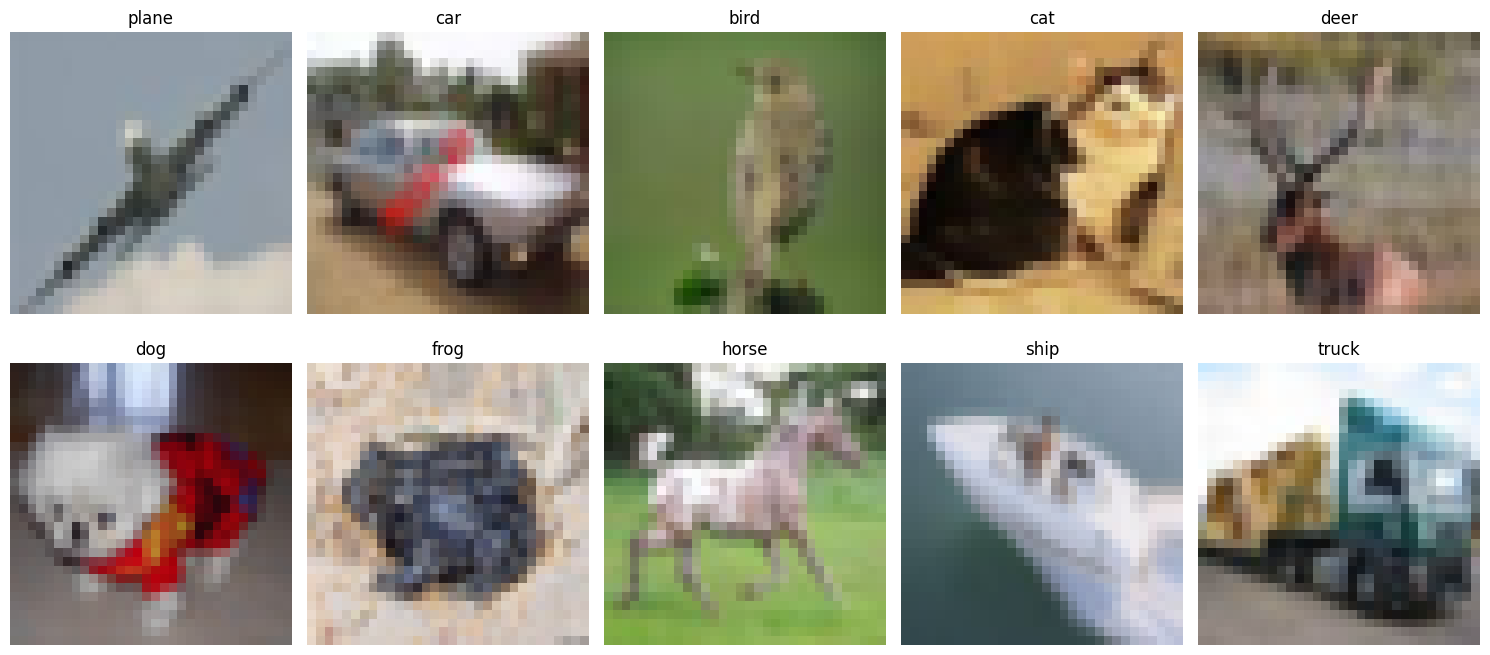

Image shape: torch.Size([3, 32, 32])
✓ All 10 CIFAR-10 classes displayed


In [14]:
# Labels for CIFAR-10 categories
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Load the CIFAR-10 dataset
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=1, shuffle=True)

# Find one example for each class
examples = {}
for images, labels in trainloader:
    label = labels.item()
    if label not in examples:
        examples[label] = images[0]
    if len(examples) == 10:
        break

# Plot one example for each class
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for i in range(10):
    ax = axes[i // 5, i % 5]
    img = examples[i].permute(1, 2, 0) # Rearranging channels for plotting
    ax.imshow(img)
    ax.set_title(f"{classes[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {examples[0].shape}")
print("✓ All 10 CIFAR-10 classes displayed")

<div class="alert alert-info">

### 👀 Data Observations

- **Resolution:** You will notice that the images are not exactly high resolution but they still contain enough information for a model to learn to calssify them to a certain degree.
- **Shape Recap:** Every image consists of 3x32x32 numbers forming a block numbers with dimension`[3, 32, 32]`. The `3` represents the three values needed per pixel to represent colours (how much Red, Green, and Blue per pixel).
- **Real-World Detail:** Notice how different a 'bird' can look depending on its pose, or how 'ships' and 'planes' both often have blue backgrounds. Our model has to learn the difference between water, sky, and the object itself!

</div>

---

## <span style="color: purple;">Step 2 - The "Flat" Model</span>

Our first model treats the image just like a long table of measurements. It stretches the image into one long list of **3,072 numbers** (32 x 32 x 3).

In [ ]:
class FlatNet(nn.Module):
    def __init__(self):
        super().__init__()
        # The input size is 3*32*32 = 3072 features
        self.linear = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.linear(x)

model_flat = FlatNet()
print("✓ Flat model defined")

---

## <span style="color: purple;">Step 3 - The "ConvNet" Model</span>

A **Convolutional Neural Network (CNN)** is specifically designed for 2D grids. Instead of flattening the features immediately, it uses filters to scan the 3x32x32 tensor to find spatial patterns like edges and textures.

In [ ]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Scanning for 16 patterns using a 3x3 filter
        self.conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(16 * 16 * 16, 10) # 16 channels, half width/height

    def forward(self, x):
        x = torch.relu(self.conv(x))
        x = self.pool(x)
        x = x.view(-1, 16 * 16 * 16)
        x = self.fc(x)
        return x

model_cnn = ConvNet()
print("✓ CNN model defined")

---

## <span style="color: purple;">Step 4 - Train Both Models</span>

Let's see how much faster the CNN can learn compared to the Flat model.

In [ ]:
# Re-loading with a larger batch for training speed
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
dataiter = iter(trainloader)

criterion = nn.CrossEntropyLoss()
optimizer_flat = optim.SGD(model_flat.parameters(), lr=0.01)
optimizer_cnn = optim.SGD(model_cnn.parameters(), lr=0.01)

history_flat = []
history_cnn = []
steps = 150 

print("Training models...")
for i in tqdm(range(steps)):
    try: 
        imgs, lbls = next(dataiter)
    except StopIteration:
        dataiter = iter(trainloader)
        imgs, lbls = next(dataiter)
    
    # Train FlatNet
    optimizer_flat.zero_grad()
    out_flat = model_flat(imgs)
    loss_flat = criterion(out_flat, lbls)
    loss_flat.backward()
    optimizer_flat.step()
    history_flat.append(loss_flat.item())
    
    # Train ConvNet
    optimizer_cnn.zero_grad()
    out_cnn = model_cnn(imgs)
    loss_cnn = criterion(out_cnn, lbls)
    loss_cnn.backward()
    optimizer_cnn.step()
    history_cnn.append(loss_cnn.item())

print("✓ Training complete")

---

## <span style="color: purple;">Step 5 - Compare Results</span>

We plot the "Loss" (the error rate). A lower line means the model is getting better at its job.

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_flat, label='Flat Model (Linear)')
plt.plot(history_cnn, label='CNN Model (Convolutional)')
plt.title('Learning Progress: Flat vs CNN')
plt.xlabel('Training Steps')
plt.ylabel('Error Rate (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("✓ Comparison chart shown")

---

## <span style="color: purple;">✅ Summary</span>

Convolutional Neural Networks excel at visual tasks because they respect the grid structure of an image and scan for patterns across colour channels.

| Key word | Meaning |
|---|---|
| RGB Channels | The Red, Green, and Blue layers that make each pixel colourful. |
| Features 💪 | In an image, every pixel's intensity is an individual measurement used for prediction. |
| CNN | An AI architecture that preserved the grid shape of an image to find patterns. |
| Flat Model | A simpler model that stretches an image into a 1D list, losing its spatial info. |
| CIFAR-10 | A famous dataset of 10 categories of colour photos (32x32 size). |

---

## <span style="color: purple;">🔧 Your turn!</span>

In the CNN model definition (back in Step 3), we asked it to scan for **16 patterns**. 

**Try changing that 16 to 4 or 64 in the line `nn.Conv2d(3, 16, ...)`. Remember, you'll also need to update the flattened size below it. Re-run to see how it affects the speed of learning!**

---

## <span style="color: purple;">🧠 Quiz</span>

Check your understanding of colour channels and CNNs.

In [ ]:
from quiz import run_b10_quiz
run_b10_quiz()